# Unterstanding key4hep jet clustering

I use this file (`/eos/experiment/fcc/prod/fcc/ee/test_spring2024/240gev/Hbb/CLD_o2_v05/rec/00016783/000/Hbb_rec_16783_1.root`, also found here: `/afs/cern.ch/work/s/saaumill/public/analyses/symlink_Hxx_fullsim/Hxx/test`) and once use the `RefinedVertexJets` (Step 1 and 2) and once the `VertexJets` (Step 1) and compare their distributions

In [1]:
path_1 = "/afs/cern.ch/work/s/saaumill/public/MyFCCAnalyses/outputs/treemaker/fullsimtagger_jetbased/Hbb_from_key4hep_VertexJets.root"
path_2 = "/afs/cern.ch/work/s/saaumill/public/MyFCCAnalyses/outputs/treemaker/fullsimtagger_jetbased/Hbb_from_key4hep.root"

In [2]:
import uproot 
import numpy as np
import matplotlib.pyplot as plt

from helper_jetobs import *

# set the style
from cycler import cycler
import matplotlib

plt.rc('axes', prop_cycle=cycler('color', ['#73b06f', '#e6701b', '#007090', '#e7298a', '#802392', '#ffad08', '#56b4e9']))
#matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["font.family"] = "serif"

# Set font sizes
matplotlib.rcParams.update(
    {
        "font.size": 14,  # General font size
    }
)

%load_ext autoreload
%autoreload 2

In [3]:
save_status = False  # Set to False if you do not want to save the plots

In [4]:
file_1 = uproot.open(path_1)
tree_1 = file_1["JetConstituentObservables;1"]

file_2 = uproot.open(path_2)
tree_2 = file_2["JetConstituentObservables;1"]

# adapt the size of the data you want to load here
df_1 = tree_1.arrays(library="np", entry_start=0, entry_stop=2000) 
df_2 = tree_2.arrays(library="np", entry_start=0, entry_stop=2000)

Plot the number of constituents per jet

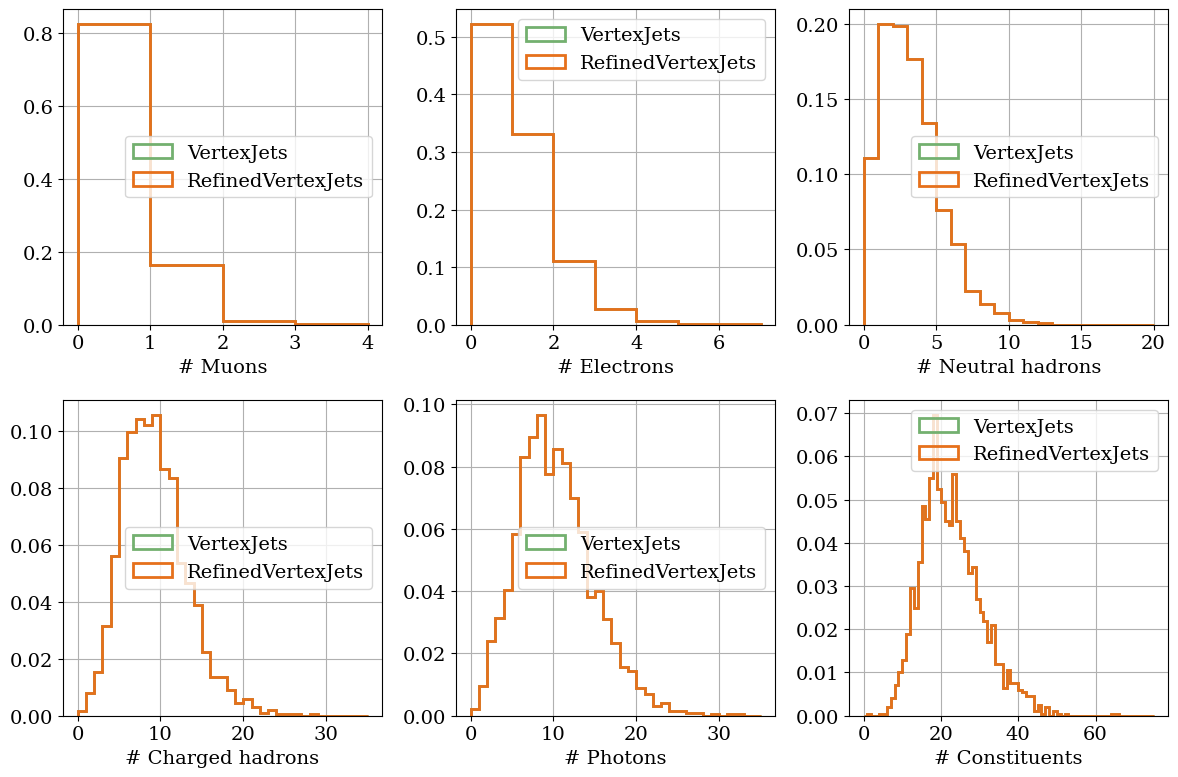

In [5]:
plot_nconst(df_1, df_2, l1="VertexJets", l2="RefinedVertexJets", save=save_status)

In [14]:
n_pfos = df_1["n_pfos"]
n_const= np.array([len(arr) for arr in df_1["pfcand_e"]])


In [19]:
i = 2 # even numbers, so that the correct jet pairs are used

In [20]:
print("First n pfos: ", n_pfos[i])
print("First n const VertexJets: ", n_const[i]+ n_const[i+1])

First n pfos:  69
First n const VertexJets:  49


In [9]:
print("First nconstituent of FCCAnalyses: ", nconst_FCCAnalyses[i+1])
print("First nconstituent of key4hep: ", nconst_key4hep[i+1])

First nconstituent of FCCAnalyses:  14
First nconstituent of key4hep:  14


In [10]:
print("Total amount of constituents in FCCAnalyses: ", nconst_FCCAnalyses[i] + nconst_FCCAnalyses[i+1])
print("Total amount of constituents in key4hep: ", nconst_key4hep[i] + nconst_key4hep[i+1])

Total amount of constituents in FCCAnalyses:  42
Total amount of constituents in key4hep:  42


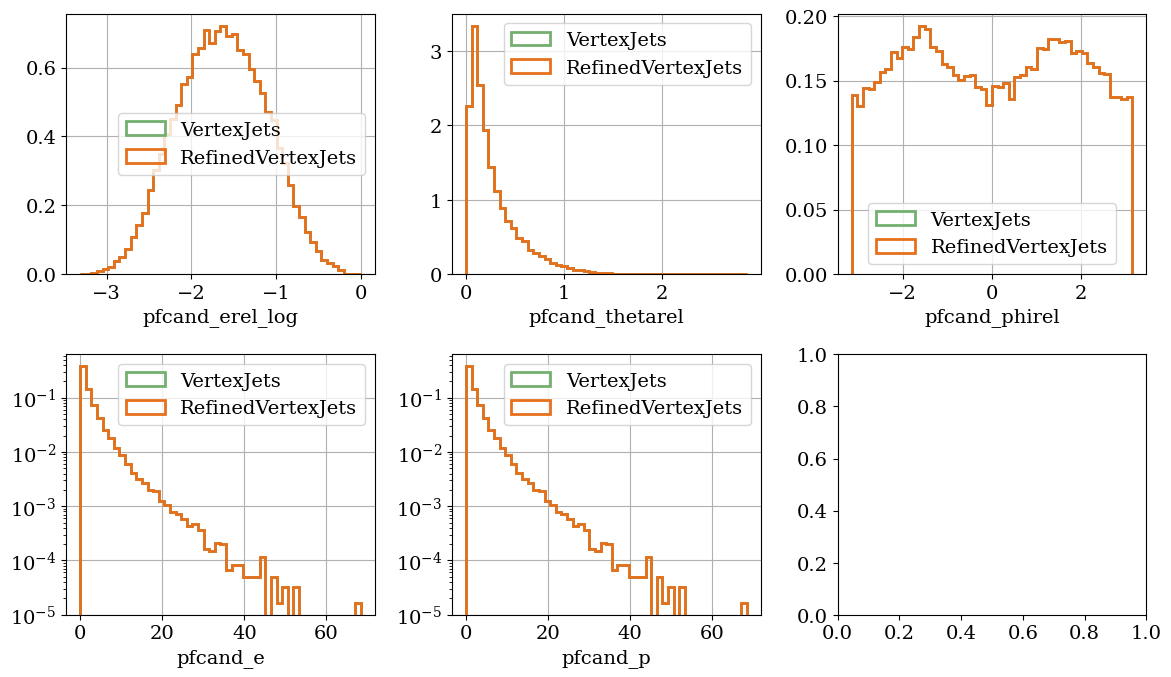

In [11]:
plot_kinematics(df_1, df_2,  l1="VertexJets", l2="RefinedVertexJets")

In [12]:
# these are lists because there might not always be 3 charged particles
index_charged_3E_1 = get_value_highest_energy_particle(df_1)
index_charged_3E_2 = get_value_highest_energy_particle(df_2)

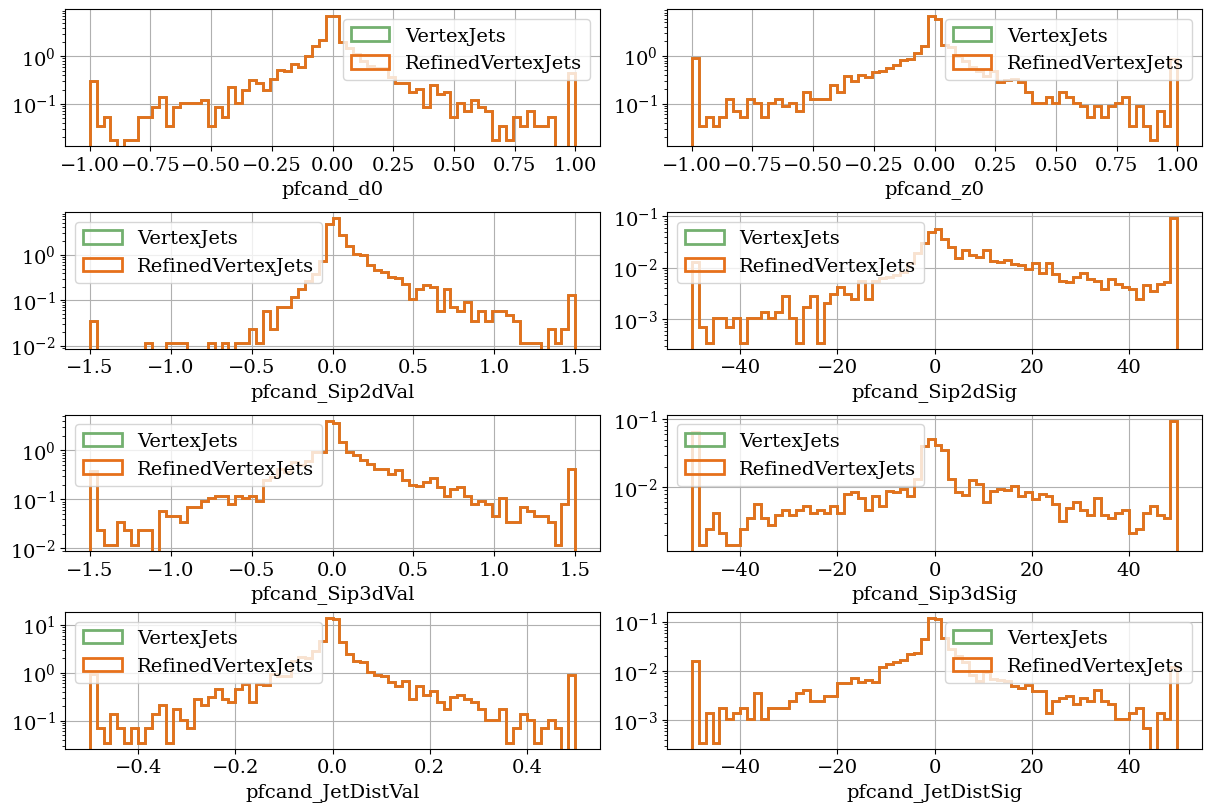

In [13]:
plot_IP(df_1, df_2, index_charged_3E_1, index_charged_3E_2,  l1="VertexJets", l2="RefinedVertexJets")